In [1]:
from datetime import datetime, timedelta
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import talib
from multiprocessing import Process, Manager

from samples.myStrategy import myStrategy as baseline_strategy

## Load Data

In [2]:
path = 'data/0050.TW.csv'
df = pd.read_csv(path)

adj_close = df['Adj Close']
date = df['Date']
date_set = set(date)
date_idx = pd.Index(date)

## Analysis

In [3]:
def set_title(beg_idx: int, end_idx: int, super: bool = False):
  day_num = end_idx - beg_idx + 1
  title = f'{date[beg_idx]} ~ {date[end_idx]}\n{day_num} trade days'
  if super:
    plt.suptitle(title)
  else:
    plt.title(title, fontsize=10)

In [4]:
def plot_rsi(
  close_price: np.ndarray,
  short_period: int, long_period: int
):
  fast = talib.RSI(close_price, timeperiod=short_period)
  slow = talib.RSI(close_price, timeperiod=long_period)

  plt.plot(fast, 'tab:orange')
  plt.plot(slow, 'tab:blue')

def plot_macd(
    close_price: np.ndarray,
    short_period: int, long_period: int, signal_period: int
):
  macd, signal, _ = talib.MACD(close_price, short_period, long_period, signal_period)

  plt.plot(macd, 'tab:orange')
  plt.plot(signal, 'tab:blue')

In [5]:
def plot_actions(close_price: np.ndarray, actions: list):
  buy = []
  sell = []

  for i, action in enumerate(actions):
    if action == 1:
      buy.append(close_price[i])
      sell.append(None)
    elif action == -1:
      buy.append(None)
      sell.append(close_price[i])
    else:
      buy.append(None)
      sell.append(None)

  plt.plot(buy, color='red', marker='^')
  plt.plot(sell, color='green', marker='v')

In [6]:
def get_nearest_workday_idx(date_str: str) -> int:
  ori_date = datetime.strptime(date_str, '%Y-%m-%d')
  date = ori_date

  delta_days = 1

  while date.strftime('%Y-%m-%d') not in date_set:
    date = ori_date + timedelta(days=delta_days)
    delta_days = -delta_days if delta_days > 0 else (-delta_days + 1)

  idx = date_idx.get_loc(date.strftime('%Y-%m-%d'))

  return idx

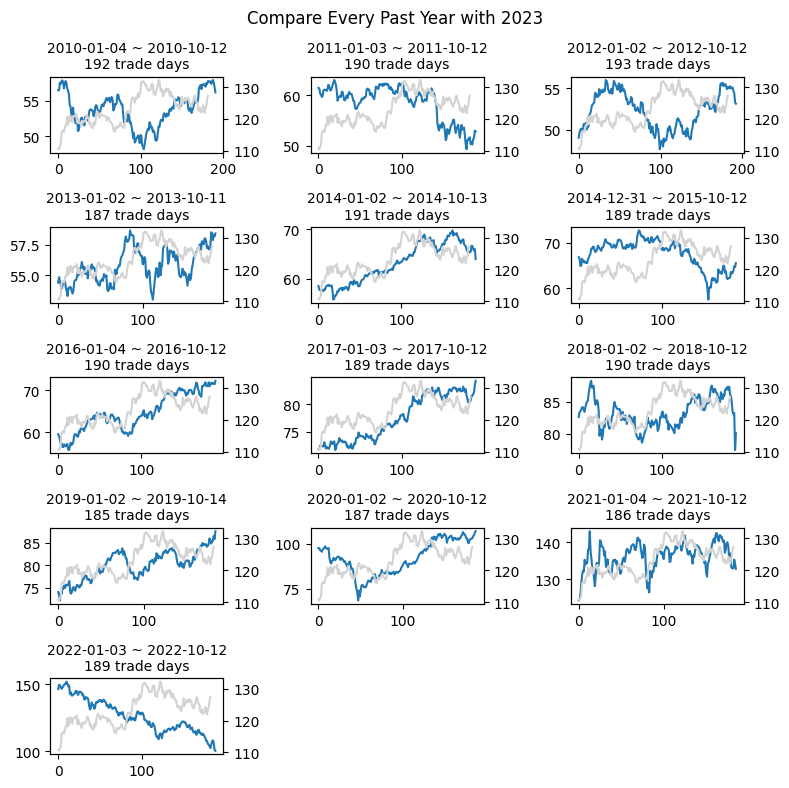

,rho
2017,0.734975
2014,0.723048
2016,0.564660
2019,0.433915
2021,0.390049
2020,0.312990
2013,0.254108
2018,0.108108
2015,-0.186388
2011,-0.232474


In [7]:
fig = plt.figure(figsize=(8, 8))

beg_idx = date_idx.get_loc('2023-01-03')
end_idx = date_idx.get_loc('2023-10-12')
close_price_2023 = adj_close[beg_idx:end_idx + 1].values

corr_list = pd.Series()

for y in range(2010, 2023):
  beg_idx = get_nearest_workday_idx(f'{y}-01-02')
  end_idx = get_nearest_workday_idx(f'{y}-10-12')
  close_price = adj_close[beg_idx:end_idx + 1].values

  min_len = min(close_price.shape[0], close_price_2023.shape[0])
  corr = np.corrcoef(close_price[:min_len], close_price_2023[:min_len])[0][1]
  corr_list[y] = corr

  plt.subplot(5, 3, y - 2009)
  set_title(beg_idx, end_idx)
  plt.plot(close_price)
  plt.twinx()
  plt.plot(close_price_2023, 'lightgray')

plt.suptitle(f'Compare Every Past Year with 2023')
plt.tight_layout()
plt.show()

rho = corr_list.sort_values(ascending=False)
pd.DataFrame({ 'rho': rho })

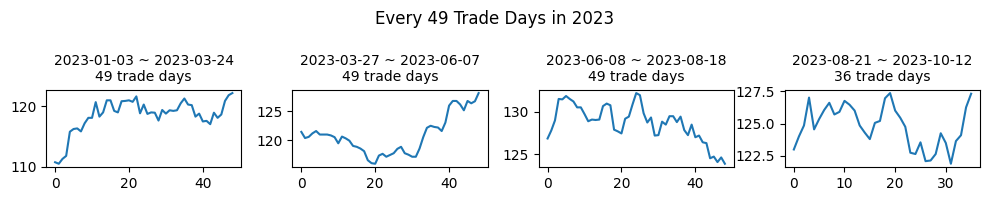

In [8]:
fig = plt.figure(figsize=(10, 2))

n = 49
interval = date[date.str.startswith('2023-')]
splits = [interval[i:i+n] for i in range(0, interval.shape[0], n)]
for i, split in enumerate(splits):
  beg_idx = split.index[0]
  end_idx = split.index[-1]
  close_price = adj_close[beg_idx:end_idx + 1].values

  plt.subplot(1, 4, i + 1)
  set_title(beg_idx, end_idx)
  plt.plot(close_price)

plt.suptitle(f'Every {n} Trade Days in 2023')
plt.tight_layout()
plt.show()

## Strategy
### Construction

In [9]:
def get_baseline_strategy_actions(prices: np.ndarray, beg_idx: int) -> list:
	actions = []

	for i in range(beg_idx, prices.shape[0]):
		action = baseline_strategy(prices[0:i], prices[i])
		actions.append(action)

	return actions

In [10]:
# optimal strategy
def get_best_actions(prices: np.ndarray, beg_idx: int) -> list:
  n = prices.shape[0] - beg_idx  # since we don't consider data before the target testing interval
  cash = np.zeros(n)
  stocks = np.zeros(n)
  action_logs = np.zeros((2, n))

  cash[0] = 1000
  stocks[0] = cash[0] / prices[beg_idx]
  action_logs[1][0] = 1

  for i in range(1, n):
    new_cash = stocks[i - 1] * prices[beg_idx + i]
    new_stock = cash[i - 1] / prices[beg_idx + i]

    if cash[i - 1] >= new_cash:
      cash[i] = cash[i - 1]
      action_logs[0][i] = 0
    else:
      cash[i] = new_cash
      action_logs[0][i] = -1

    if stocks[i - 1] >= new_stock:
      stocks[i] = stocks[i - 1]
      action_logs[1][i] = 0
    else:
      stocks[i] = new_stock
      action_logs[1][i] = 1

  idx = 0
  actions = []

  for i in range(n - 1, -1, -1):
    actions.append(action_logs[idx][i])
    if action_logs[idx][i] != 0:
      idx = 1 - idx

  return actions[::-1]

In [11]:
def get_rsi_strategy_actions(
  prices: np.ndarray, beg_idx: int,
  action_rise_above: int, action_fall_below: int,
  fast_ws: int, slow_ws: int,
  alpha: float, beta: float
) -> list:
  actions = []

  fast_rsi = talib.RSI(prices, timeperiod=fast_ws)
  slow_rsi = talib.RSI(prices, timeperiod=slow_ws)

  for i in range(beg_idx, prices.shape[0]):
    diff = fast_rsi[i] - slow_rsi[i]
    diff_prev = fast_rsi[i - 1] - slow_rsi[i - 1]

    if (beta < diff and diff < 0 and prices[i] > prices[i - 1]) or (diff > 0 and diff_prev <= 0):
      actions.append(action_rise_above)
    elif (0 < diff and diff < alpha and prices[i] < prices[i - 1]) or (diff < 0 and diff_prev >= 0):
      actions.append(action_fall_below)
    else:
      actions.append(0)

  return actions

In [12]:
def get_macd_strategy_actions(
  prices: np.ndarray, beg_idx: int,
  action_rise_above: int, action_fall_below: int,
  fastperiod: int, slowperiod: int, signalperiod: int,
  alpha: float, beta: float
) -> list:
  actions = []

  _, _, hist = talib.MACD(prices, fastperiod, slowperiod, signalperiod)

  for i in range(beg_idx, prices.shape[0]):
    if (beta < hist[i] and hist[i] < 0 and prices[i] > prices[i - 1]) or (hist[i] > 0 and hist[i - 1] <= 0):
      actions.append(action_rise_above)
    elif (0 < hist[i] and hist[i] < alpha and prices[i] < prices[i - 1]) or (hist[i] < 0 and hist[i - 1] >= 0):
      actions.append(action_fall_below)
    else:
      actions.append(0)

  return actions

In [13]:
def get_ma_strategy_actions(
    prices: np.ndarray, beg_idx: int,
    fast_ws: int, slow_ws: int,
    alpha: float, beta: float
) -> list:
  actions = []

  fast_ma = talib.EMA(prices, fast_ws)
  slow_ma = talib.EMA(prices, slow_ws)

  for i in range(beg_idx, prices.shape[0]):
    diff = fast_ma[i] - slow_ma[i]
    diff_prev = fast_ma[i - 1] - slow_ma[i - 1]

    if (beta < diff and diff < 0 and prices[i] > prices[i - 1]) or (diff > 0 and diff_prev <= 0):
      actions.append(1)
    elif (0 < diff and diff < alpha and prices[i] < prices[i - 1]) or (diff < 0 and diff_prev >= 0):
      actions.append(-1)
    else:
      actions.append(0)

  return actions

In [14]:
def get_rsi_bound_strategy_actions(
  prices: np.ndarray, beg_idx: int,
  ws: int, alpha: int, beta: int
) -> list:
  actions = []

  rsi = talib.RSI(prices, timeperiod=ws)

  for i in range(beg_idx, prices.shape[0]):
    if rsi[i] > alpha:
      actions.append(-1)
    elif rsi[i] < beta:
      actions.append(1)
    else:
      actions.append(0)

  return actions

In [15]:
def get_hybrid_strategy_actions(
  prices: np.ndarray, beg_idx: int,
  rsi_ws: int, rsi_alpha: int, rsi_beta: int,
  fastperiod: int, slowperiod: int, signalperiod: int,
  macd_alpha: float, macd_beta: float
) -> list:
  actions = []

  rsi = talib.RSI(prices, rsi_ws)
  _, _, hist = talib.MACD(prices, fastperiod, slowperiod, signalperiod)

  for i in range(beg_idx, prices.shape[0]):
    rsi_oversold = rsi[i] < rsi_beta
    rsi_overbought = rsi[i] > rsi_alpha
    macd_buy = (macd_beta < hist[i] and hist[i] < 0 and prices[i] > prices[i - 1]) or \
      (hist[i] > 0 and hist[i - 1] <= 0)
    macd_sell = (0 < hist[i] and hist[i] < macd_alpha and prices[i] < prices[i - 1]) or \
      (hist[i] < 0 and hist[i - 1] >= 0)

    if macd_buy and not rsi_overbought:
      actions.append(1)
    elif macd_sell and not rsi_oversold:
      actions.append(-1)
    elif rsi_overbought:
      actions.append(-1)
    elif rsi_oversold:
      actions.append(1)
    else:
      actions.append(0)

  return actions

### Fitting

In [16]:
def calculate_return_rate(prices: np.ndarray, actions: list) -> float:
	capital = 1000
	stock_holding = 0

	for i, action in enumerate(actions):
		curr_price = prices[i]
		if action == 1 and capital > 0:
			stock_holding = capital / curr_price
			capital = 0
		elif action == -1 and stock_holding > 0:
			capital = stock_holding * curr_price
			stock_holding = 0

	final = capital + stock_holding * curr_price
	return (final - 1000) / 1000

#### 1. Specify Fitting Interval

In [17]:
n = 49
fit_interval = date[date.str.startswith('2017-')]
history_beg = fit_interval.index[0] - n
fit_splits = [(i, i + n) for i in range(fit_interval.index[0], fit_interval.index[-1] + 1, n)]

In [18]:
proc_num = 32

#### 2. RSI Strategy

In [19]:
param_names_rsi = (
  'action_rise_above',
  'action_fall_below',
  'fast_ws',
  'slow_ws',
  'alpha',
  'beta'
)

args = []
for fast_ws in range(2, 21):
  for slow_ws in range(fast_ws + 1, 41):
    for alpha in np.arange(0.1, 0.4, 0.1):
      for beta in np.arange(-0.1, -0.4, -0.1):
        args.append((fast_ws, slow_ws, alpha, beta))

size_per_proc = len(args) // proc_num

m = Manager()
local_max_rr = m.Array('d', [ 0 ] * proc_num)
local_best_fast_ws = m.Array('i', [ 0 ] * proc_num)
local_best_slow_ws = m.Array('i', [ 0 ] * proc_num)
local_best_alpha = m.Array('d', [ 0 ] * proc_num)
local_best_beta = m.Array('d', [ 0 ] * proc_num)

def job(idx, action_rise_above, action_fall_below, args):
  local_max_rr[idx] = 0

  for fast_ws, slow_ws, alpha, beta in args:
    total_rr = 0

    for split in fit_splits:
      prices = adj_close[history_beg:split[1]].values
      trade_np_beg = split[0] - history_beg
      actions = get_rsi_strategy_actions(
        prices, trade_np_beg,
        action_rise_above, action_fall_below,
        fast_ws, slow_ws,
        alpha, beta
      )
      total_rr += calculate_return_rate(prices[trade_np_beg:], actions)

    if total_rr > local_max_rr[idx]:
      local_max_rr[idx] = total_rr
      local_best_fast_ws[idx] = fast_ws
      local_best_slow_ws[idx] = slow_ws
      local_best_alpha[idx] = alpha
      local_best_beta[idx] = beta

best_params_rsi = [ None ] * 2

action_rise_above = 1
action_fall_below = -1

for dir in range(2):
  procs = []
  beg = 0
  end = size_per_proc

  for idx in range(proc_num):
    if idx == proc_num - 1:
      end = len(args)

    p = Process(
      target=job,
      args=(idx, action_rise_above, action_fall_below, args[beg:end])
    )
    p.start()
    procs.append(p)

    beg = end
    end += size_per_proc

  for p in procs:
    p.join()

  max_rr = 0
  for i, rr in enumerate(local_max_rr):
    if rr > max_rr:
      max_rr = rr
      best_params_rsi[dir] = (
        action_rise_above, action_fall_below,
        local_best_fast_ws[i], local_best_slow_ws[i],
        local_best_alpha[i], local_best_beta[i]
      )

  print('[Original]' if dir == 0 else '\n[Inverse]')
  print(f'Maximized Total Return Rate: {max_rr * 100:.2f}%')
  print('Best Params:')
  for name, value in zip(param_names_rsi[2:], best_params_rsi[dir][2:]):
    print(f'- {name}: {value}')

  action_rise_above, action_fall_below = action_fall_below, action_rise_above

best_params_dict_rsi = [dict(zip(param_names_rsi, best_params_rsi[dir])) for dir in range(2)]

[Original]
Maximized Total Return Rate: 14.03%
Best Params:
- fast_ws: 20
- slow_ws: 24
- alpha: 0.30000000000000004
- beta: -0.4

[Inverse]
Maximized Total Return Rate: 12.57%
Best Params:
- fast_ws: 9
- slow_ws: 33
- alpha: 0.1
- beta: -0.1


#### 3. MACD Strategy

In [20]:
param_names_macd = (
  'action_rise_above',
  'action_fall_below',
  'fastperiod',
  'slowperiod',
  'signalperiod',
  'alpha',
  'beta'
)

best_params_macd = [ None ] * 2

action_rise_above = 1
action_fall_below = -1

for dir in range(2):
  max_rr = 0

  for signalperiod in range(2, 21):
    for fastperiod in range(signalperiod + 1, 31):
      for slowperiod in range(fastperiod + 1, 41):
        for alpha in np.arange(0.1, 0.4, 0.1):
          for beta in np.arange(-0.1, -0.4, -0.1):
            total_rr = 0

            for split in fit_splits:
              prices = adj_close[history_beg:split[1]].values
              trade_np_beg = split[0] - history_beg
              actions = get_macd_strategy_actions(
                prices, trade_np_beg,
                action_rise_above, action_fall_below,
                fastperiod, slowperiod, signalperiod,
                alpha, beta
              )
              total_rr += calculate_return_rate(prices[trade_np_beg:], actions)

            if total_rr > max_rr:
              max_rr = total_rr
              best_params_macd[dir] = (
                action_rise_above, action_fall_below,
                fastperiod, slowperiod, signalperiod,
                alpha, beta
              )

  print('[Original]' if dir == 0 else '\n[Inverse]')
  print(f'Maximized Total Return Rate: {max_rr * 100:.2f}%')
  print('Best Params:')
  for name, value in zip(param_names_macd[2:], best_params_macd[dir][2:]):
    print(f'- {name}: {value}')

  action_rise_above, action_fall_below = action_fall_below, action_rise_above

best_params_dict_macd = [dict(zip(param_names_macd, best_params_macd[dir])) for dir in range(2)]

[Original]
Maximized Total Return Rate: 19.27%
Best Params:
- fastperiod: 6
- slowperiod: 28
- signalperiod: 5
- alpha: 0.1
- beta: -0.2

[Inverse]
Maximized Total Return Rate: 12.53%
Best Params:
- fastperiod: 4
- slowperiod: 5
- signalperiod: 2
- alpha: 0.1
- beta: -0.1


#### 4. MA Strategy

In [21]:
param_names_ma = (
  'fast_ws',
  'slow_ws',
  'alpha',
  'beta'
)

max_rr = 0
best_params_ma = None

for fast_ws in range(2, 21):
  for slow_ws in range(fast_ws + 1, 41):
    for alpha in np.arange(0.1, 0.4, 0.1):
      for beta in np.arange(-0.1, -0.4, -0.1):
        total_rr = 0

        for split in fit_splits:
          prices = adj_close[history_beg:split[1]].values
          trade_np_beg = split[0] - history_beg
          actions = get_ma_strategy_actions(
            prices, trade_np_beg,
            fast_ws, slow_ws,
            alpha, beta
          )
          total_rr += calculate_return_rate(prices[trade_np_beg:], actions)

        if total_rr > max_rr:
          max_rr = total_rr
          best_params_ma = (fast_ws, slow_ws, alpha, beta)

best_params_dict_ma = dict(zip(param_names_ma, best_params_ma))

print(f'Maximized Total Return Rate: {max_rr * 100:.2f}%')
print('Best Params:')
for name, value in best_params_dict_ma.items():
  print(f'- {name}: {value}')

Maximized Total Return Rate: 19.45%
Best Params:
- fast_ws: 7
- slow_ws: 11
- alpha: 0.1
- beta: -0.4


#### 5. RSI Bound Strategy

In [22]:
param_names_rsi_bound = (
  'ws',
  'alpha',
  'beta'
)

max_rr = 0
best_params_rsi_bound = None

for ws in range(2, 41):
  for alpha in range(55, 100, 5):
    for beta in range(5, 50, 5):
      total_rr = 0

      for split in fit_splits:
        prices = adj_close[history_beg:split[1]].values
        trade_np_beg = split[0] - history_beg
        actions = get_rsi_bound_strategy_actions(
          prices, trade_np_beg,
          ws, alpha, beta
        )
        total_rr += calculate_return_rate(prices[trade_np_beg:], actions)

      if total_rr > max_rr:
        max_rr = total_rr
        best_params_rsi_bound = (ws, alpha, beta)

best_params_dict_rsi_bound = dict(zip(param_names_rsi_bound, best_params_rsi_bound))

print(f'Maximized Total Return Rate: {max_rr * 100:.2f}%')
print('Best Params:')
for name, value in best_params_dict_rsi_bound.items():
  print(f'- {name}: {value}')

Maximized Total Return Rate: 17.69%
Best Params:
- ws: 5
- alpha: 90
- beta: 45


#### 6. Hybrid Strategy

In [23]:
param_names_hybrid = (
  'rsi_ws',
  'rsi_alpha',
  'rsi_beta',
  'fastperiod',
  'slowperiod',
  'signalperiod',
  'macd_alpha',
  'macd_beta'
)

args = []
for rsi_ws in range(2, 21, 2):
  for rsi_alpha in range(60, 85, 5):
    for rsi_beta in range(20, 45, 5):
      for fastperiod in range(2, 21, 2):
        for slowperiod in range(fastperiod + 2, 31, 2):
          for signalperiod in range(2, 21, 2):
            for macd_alpha in np.arange(0.1, 0.4, 0.1):
              for macd_beta in np.arange(-0.1, -0.4, -0.1):
                args.append((
                   rsi_ws, rsi_alpha, rsi_beta,
                   fastperiod, slowperiod, signalperiod,
                   macd_alpha, macd_beta
                ))

size_per_proc = len(args) // proc_num

m = Manager()
local_max_rr = m.Array('d', [ 0 ] * proc_num)
local_best_rsi_ws = m.Array('i', [ 0 ] * proc_num)
local_best_rsi_alpha = m.Array('i', [ 0 ] * proc_num)
local_best_rsi_beta = m.Array('i', [ 0 ] * proc_num)
local_best_fastperiod = m.Array('i', [ 0 ] * proc_num)
local_best_slowperiod = m.Array('i', [ 0 ] * proc_num)
local_best_signalperiod = m.Array('i', [ 0 ] * proc_num)
local_best_macd_alpha = m.Array('d', [ 0 ] * proc_num)
local_best_macd_beta = m.Array('d', [ 0 ] * proc_num)

def job(idx, args):
  for rsi_ws, rsi_alpha, rsi_beta, \
    fastperiod, slowperiod, signalperiod, \
    macd_alpha, macd_beta in args:
    total_rr = 0

    for split in fit_splits:
      prices = adj_close[history_beg:split[1]].values
      trade_np_beg = split[0] - history_beg
      actions = get_hybrid_strategy_actions(
        prices, trade_np_beg,
        rsi_ws, rsi_alpha, rsi_beta,
        fastperiod, slowperiod, signalperiod,
        macd_alpha, macd_beta
      )
      total_rr += calculate_return_rate(prices[trade_np_beg:], actions)

      if total_rr > local_max_rr[idx]:
        local_max_rr[idx] = total_rr
        local_best_rsi_ws[idx] = rsi_ws
        local_best_rsi_alpha[idx] = rsi_alpha
        local_best_rsi_beta[idx] = rsi_beta
        local_best_fastperiod[idx] = fastperiod
        local_best_slowperiod[idx] = slowperiod
        local_best_signalperiod[idx] = signalperiod
        local_best_macd_alpha[idx] = macd_alpha
        local_best_macd_beta[idx] = macd_beta

procs = []
beg = 0
end = size_per_proc

for idx in range(proc_num):
  if idx == proc_num - 1:
    end = len(args)

  p = Process(
    target=job,
    args=(idx, args[beg:end])
  )
  p.start()
  procs.append(p)

  beg = end
  end += size_per_proc

for p in procs:
  p.join()

max_rr = 0
for i, rr in enumerate(local_max_rr):
  if rr > max_rr:
    max_rr = rr
    best_params_hybrid = (
      local_best_rsi_ws[i], local_best_rsi_alpha[i], local_best_rsi_beta[i],
      local_best_fastperiod[i], local_best_slowperiod[i], local_best_signalperiod[i],
      local_best_macd_alpha[i], local_best_macd_beta[i]
    )

best_params_dict_hybrid = dict(zip(param_names_hybrid, best_params_hybrid))

print(f'Maximized Total Return Rate: {max_rr * 100:.2f}%')
print('Best Params:')
for name, value in best_params_dict_hybrid.items():
  print(f'- {name}: {value}')

Maximized Total Return Rate: 23.60%
Best Params:
- rsi_ws: 10
- rsi_alpha: 80
- rsi_beta: 40
- fastperiod: 4
- slowperiod: 8
- signalperiod: 12
- macd_alpha: 0.1
- macd_beta: -0.30000000000000004


### Testing

In [24]:
get_fitted_rsi_strategy_actions = partial(
  get_rsi_strategy_actions,
  **best_params_dict_rsi[0]
)
get_fitted_rsi_inv_strategy_actions = partial(
  get_rsi_strategy_actions,
  **best_params_dict_rsi[1]
)
get_fitted_macd_strategy_actions = partial(
  get_macd_strategy_actions,
  **best_params_dict_macd[0]
)
get_fitted_macd_inv_strategy_actions = partial(
  get_macd_strategy_actions,
  **best_params_dict_macd[1]
)
get_fitted_ma_strategy_actions = partial(
  get_ma_strategy_actions,
  **best_params_dict_ma
)
get_fitted_rsi_bound_strategy_actions = partial(
  get_rsi_bound_strategy_actions,
  **best_params_dict_rsi_bound
)
get_fitted_hybrid_strategy_actions = partial(
  get_hybrid_strategy_actions,
  **best_params_dict_hybrid
)

#### 2023-01-03 ~ 2023-10-12

In [25]:
n = 49
history_beg = date_idx.get_loc('2019-01-02')
test_interval = date[date.str.startswith('2023-')]
test_splits = [(i, i + n) for i in range(test_interval.index[0], test_interval.index[-1] + 1, n)]

In [26]:
strategies = {
  'Baseline': get_baseline_strategy_actions,
  'OPT': get_best_actions,
  'RSI': get_fitted_rsi_strategy_actions,
  'RSI_inv': get_fitted_rsi_inv_strategy_actions,
  'MACD': get_fitted_macd_strategy_actions,
  'MACD_inv': get_fitted_macd_inv_strategy_actions,
  'MA': get_fitted_ma_strategy_actions,
  'RSI_bound': get_fitted_rsi_bound_strategy_actions,
  'Hybrid': get_fitted_hybrid_strategy_actions,
}
strategy_num = len(strategies)

action_list = [[] for _ in range(strategy_num)]
rr_list = [[] for _ in range(strategy_num)]

for split in test_splits:
  prices = adj_close[history_beg:split[1]].values
  trade_np_beg = split[0] - history_beg
  for i, strategy in enumerate(strategies.values()):
    actions = strategy(prices, trade_np_beg)
    rr = calculate_return_rate(prices[trade_np_beg:], actions)

    action_list[i] += actions
    rr_list[i].append(rr)

In [27]:
res = pd.DataFrame({ name: rr_log for name, rr_log in zip(strategies.keys(), rr_list) })
res = res.transpose() * 100
res['Total'] = res.sum(axis=1)
res['Average'] = res.mean(axis=1)

with pd.option_context('display.float_format', '{:.2f}%'.format):
  display(res)

,0,1,2,3,Total,Average
Baseline,4.13%,6.31%,-2.85%,-0.99%,6.60%,2.64%
OPT,27.79%,17.42%,15.10%,16.54%,76.85%,30.74%
RSI,7.70%,6.53%,-1.72%,1.16%,13.66%,5.47%
RSI_inv,1.89%,-0.58%,-1.67%,2.05%,1.69%,0.68%
MACD,10.30%,6.08%,-3.62%,1.45%,14.21%,5.69%
MACD_inv,18.33%,-1.19%,-2.91%,-1.30%,12.93%,5.17%
MA,8.92%,6.17%,-3.01%,2.31%,14.39%,5.76%
RSI_bound,12.31%,5.14%,-4.55%,3.50%,16.40%,6.56%
Hybrid,10.16%,4.26%,-0.12%,7.65%,21.95%,8.78%


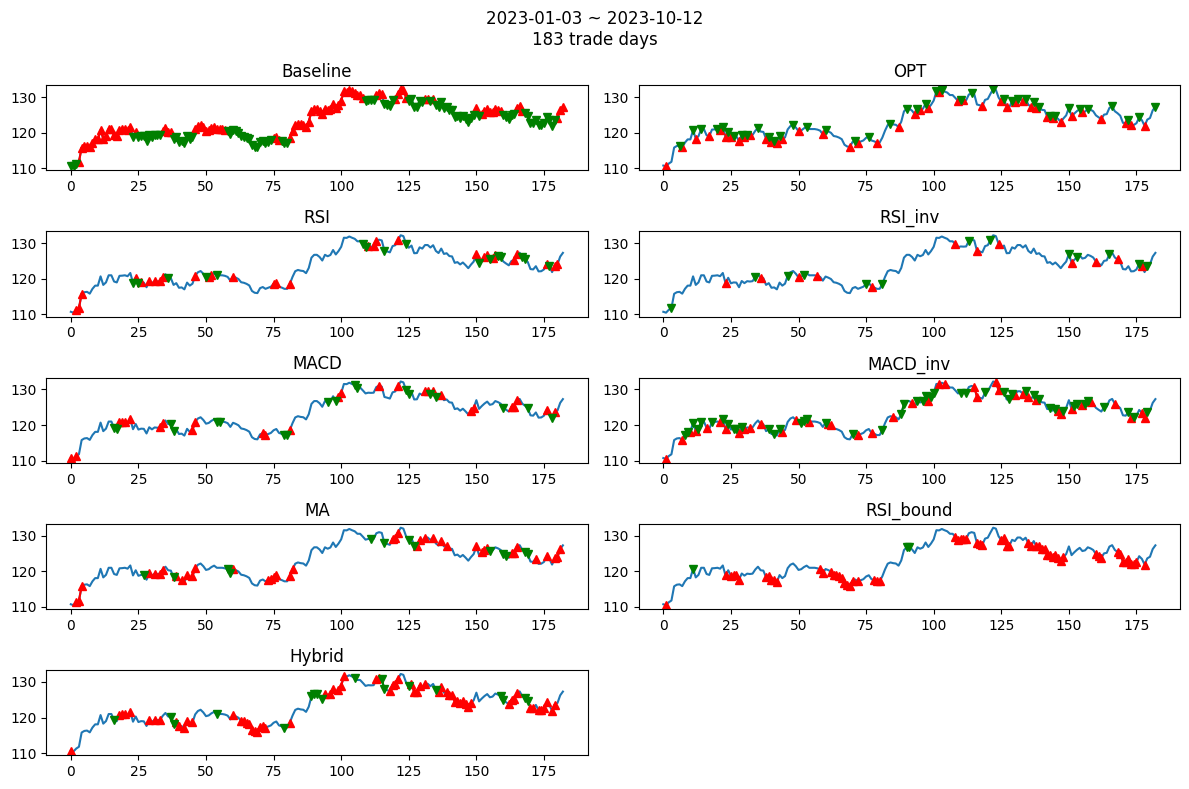

In [28]:
fig = plt.figure(figsize=(12, 8))

prices = adj_close[test_interval.index].values
for i, name in enumerate(strategies.keys()):
  plt.subplot(5, 2, i + 1)
  plt.title(name)
  plt.plot(prices)
  plot_actions(prices, action_list[i])

set_title(test_interval.index[0], test_interval.index[-1], True)
plt.tight_layout()
plt.show()

#### Nearly Every 10/16 ~ 12/22 period from 2010 to 2023

In [29]:
action_list = []
hybrid_rr_list = []
baseline_rr_list = []
best_rr_list = []

for y in range(2010, 2023):
  beg_idx = get_nearest_workday_idx(f'{y}-10-16')
  end_idx = get_nearest_workday_idx(f'{y}-12-22')
  history_beg = beg_idx - 49
  trade_np_beg = 49
  prices = adj_close[history_beg:end_idx + 1].values

  actions = get_fitted_hybrid_strategy_actions(prices, trade_np_beg)
  rr = calculate_return_rate(prices[trade_np_beg:], actions)
  action_list.append(actions)
  hybrid_rr_list.append(rr)

  actions = get_baseline_strategy_actions(prices, trade_np_beg)
  rr = calculate_return_rate(prices[trade_np_beg:], actions)
  baseline_rr_list.append(rr)

  actions = get_best_actions(prices, trade_np_beg)
  rr = calculate_return_rate(prices[trade_np_beg:], actions)
  best_rr_list.append(rr)

In [30]:
res = pd.DataFrame(
  {
    'Baseline': baseline_rr_list,
    'Hybrid': hybrid_rr_list,
    'OPT': best_rr_list,
  },
  index=range(2010, 2023)) * 100

with pd.option_context('display.float_format', '{:.2f}%'.format):
  display(res)

,Baseline,Hybrid,OPT
2010,1.17%,2.55%,17.95%
2011,-7.64%,-2.51%,28.63%
2012,1.36%,-1.03%,16.85%
2013,-0.78%,2.36%,12.85%
2014,-1.05%,4.21%,22.46%
2015,-7.78%,-5.10%,17.66%
2016,0.28%,2.87%,15.54%
2017,-0.83%,-2.92%,9.28%
2018,-4.01%,-4.98%,17.62%
2019,8.61%,8.40%,20.77%


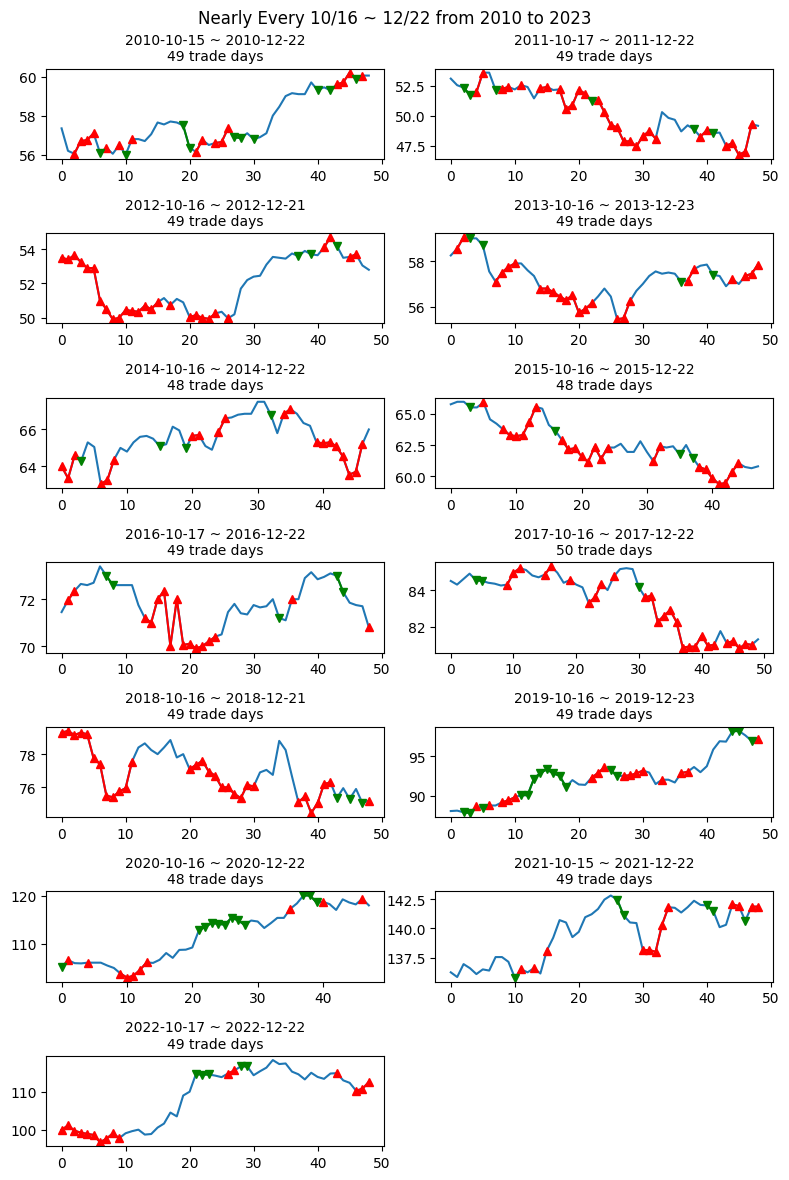

In [31]:
fig = plt.figure(figsize=(8, 12))

for y in range(2010, 2023):
  beg_idx = get_nearest_workday_idx(f'{y}-10-16')
  end_idx = get_nearest_workday_idx(f'{y}-12-22')
  prices = adj_close[beg_idx:end_idx + 1].values

  plt.subplot(7, 2, y - 2009)
  set_title(beg_idx, end_idx)
  plt.plot(prices)
  plot_actions(prices, action_list[y - 2010])

plt.suptitle('Nearly Every 10/16 ~ 12/22 from 2010 to 2023')
plt.tight_layout()
plt.show()